## 热力度简单完整案例

100 x 100 的图，30 x 50 和 60 x 80 是热力中心

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

np.random.seed(42)

In [2]:
## 
core_point1 = (30, 50)
core_point2 = (60, 80)
Sigma = 10
n_points = 500

x1 = np.random.normal(core_point1[0], Sigma, n_points)
y1 = np.random.normal(core_point1[1], Sigma, n_points)

x2 = np.random.normal(core_point2[0], Sigma, n_points)
y2 = np.random.normal(core_point2[1], Sigma, n_points)

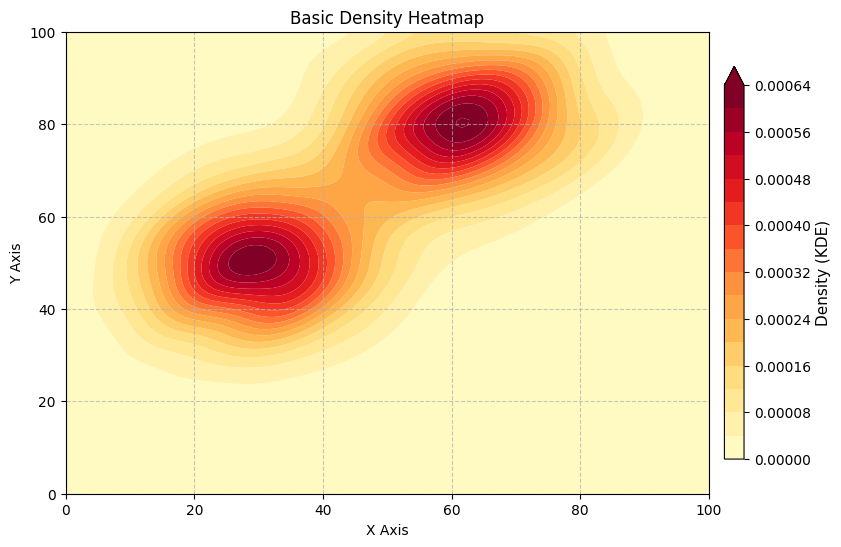

In [5]:
# 绘制散点图
fig = plt.figure(figsize=(10, 6))
ax = plt.axes()


# ========================================
# 核心：KDE核密度估计
# ========================================

# 1. 将数据打包成 [2, N] 格式
values = np.vstack([
    np.concatenate([x1, x2]),
    np.concatenate([y1, y2])
    ])

# 2. 创建KDE模型
# bw_method: 带宽，值越小越尖锐，越大越平滑
kde = gaussian_kde(values, bw_method=0.3)

# 3. 创建评估网格
x_grid_kde = np.linspace(0, 100, 100)
y_grid_kde = np.linspace(0, 100, 100)
xx, yy = np.meshgrid(x_grid_kde, y_grid_kde)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])

# 4. 计算密度
density = kde(grid_coords).reshape(xx.shape)
# 5. 高斯平滑（可选，让图更柔和）
density = gaussian_filter(density, sigma=2)

# 6. 定义颜色映射
colors = [
    "#ffffcc", "#ffeda0", "#fed976", "#feb24c",
    "#fd8d3c", "#fc4e2a", "#e31a1c", "#bd0026", "#800026"
]
cmap = mcolors.LinearSegmentedColormap.from_list('heatmap', colors, N=256)

# 7. 绘制等高线填充图
vmax = np.percentile(density, 99.5)  # 用99.5分位数避免极值影响
im = ax.contourf(xx, yy, 
                 density,
                 levels=20,           # 等高线数量
                 cmap=cmap,
                 vmax=vmax,
                 extend='max',
                #  transform=projection,
                 antialiased=True)

# 颜色条
cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Density (KDE)', fontsize=11)

# sc = ax.scatter(
#     np.concatenate([x1, x2]),
#     np.concatenate([y1, y2]),
#     s=10,  # 点大小
#     c="red",  # 颜色
#     alpha=0.5,  # 透明度
#     # transform=projection,
# )

ax.set_xlim(0, 100)  # 设置横坐标轴范围
ax.set_ylim(0, 100)  # 设置纵坐标轴范围
plt.title('Basic Density Heatmap')
plt.grid(True, linestyle='--', alpha=0.7)  # 可选：添加参考网格
plt.xlabel('X Axis')  # 可选：添加坐标轴标签
plt.ylabel('Y Axis')  # 可选：添加坐标轴标签
plt.show()

## 经纬度热力图

先找到经纬度数据

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

np.random.seed(42)

In [ ]:
df = pd.read_csv("data/景区数据.csv")
lats = df.iloc[:, 6].values
lons = df.iloc[:, 7].values